# Installing Python Packages
 I'm installing essential Python packages in my workspace.

In [ ]:
# Get the 'stim' library, a fast tool for quantum simulations, specifically version 1.14.
!pip install stim==1.14
# Get the 'numpy' library for working with numbers in Python.
!pip install numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 7.8 MB/s eta 0:00:00


# Checking Versions
I am checking the version of the above-installed Python package, Stim.

In [ ]:
# Bring in the 'stim' library so we can use its functions.
import stim
# Show which version of 'stim' we are using to make sure it's the right one.
print(stim.__version__)

1.14.0


# Generating Circuit
I'm going to generate a quantum error-correcting circuit called "Repetition Circuit". For this purpose, I am using a code distance d=9 that will generate a circuit of a total of 17 qubits (indexed from 0 through 16). This circuit has 9 data qubits (controlled qubits) and 8 ancilla (target qubits).

In [ ]:
circuit = stim.Circuit.generated(
    "repetition_code:memory",                 # Create a special quantum circuit called a 'repetition code' to protect quantum information in memory.
    rounds=25,                                # Run the error correction process 25 times to see how errors change over time.
    distance=9,                               # Set the size of the code (distance 'd') to 9. This impacts how many qubits are used and how well it can fix errors.
    before_round_data_depolarization=0.04,    # Add a 4% chance of a specific type of error (depolarizing error) to our main data qubits before each error correction round, simulating real-world noise.
    before_measure_flip_probability=0.01)     # Add a 1% chance of a qubit flipping (an X error) right before we measure it, simulating errors during measurement.
# Show a detailed text description of the quantum circuit we just made.
print(repr(circuit))

stim.Circuit('''
    R 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16
    TICK
    DEPOLARIZE1(0.04) 0 2 4 6 8 10 12 14 16
    CX 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15
    TICK
    CX 2 1 4 3 6 5 8 7 10 9 12 11 14 13 16 15
    TICK
    X_ERROR(0.01) 1 3 5 7 9 11 13 15
    MR 1 3 5 7 9 11 13 15
    DETECTOR(1, 0) rec[-8]
    DETECTOR(3, 0) rec[-7]
    DETECTOR(5, 0) rec[-6]
    DETECTOR(7, 0) rec[-5]
    DETECTOR(9, 0) rec[-4]
    DETECTOR(11, 0) rec[-3]
    DETECTOR(13, 0) rec[-2]
    DETECTOR(15, 0) rec[-1]
    REPEAT 24 {
        TICK
        DEPOLARIZE1(0.04) 0 2 4 6 8 10 12 14 16
        CX 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15
        TICK
        CX 2 1 4 3 6 5 8 7 10 9 12 11 14 13 16 15
        TICK
        X_ERROR(0.01) 1 3 5 7 9 11 13 15
        MR 1 3 5 7 9 11 13 15
        SHIFT_COORDS(0, 1)
        DETECTOR(1, 0) rec[-8] rec[-16]
        DETECTOR(3, 0) rec[-7] rec[-15]
        DETECTOR(5, 0) rec[-6] rec[-14]
        DETECTOR(7, 0) rec[-5] rec[-13]
        DETECTOR(9, 0) rec[-4] r

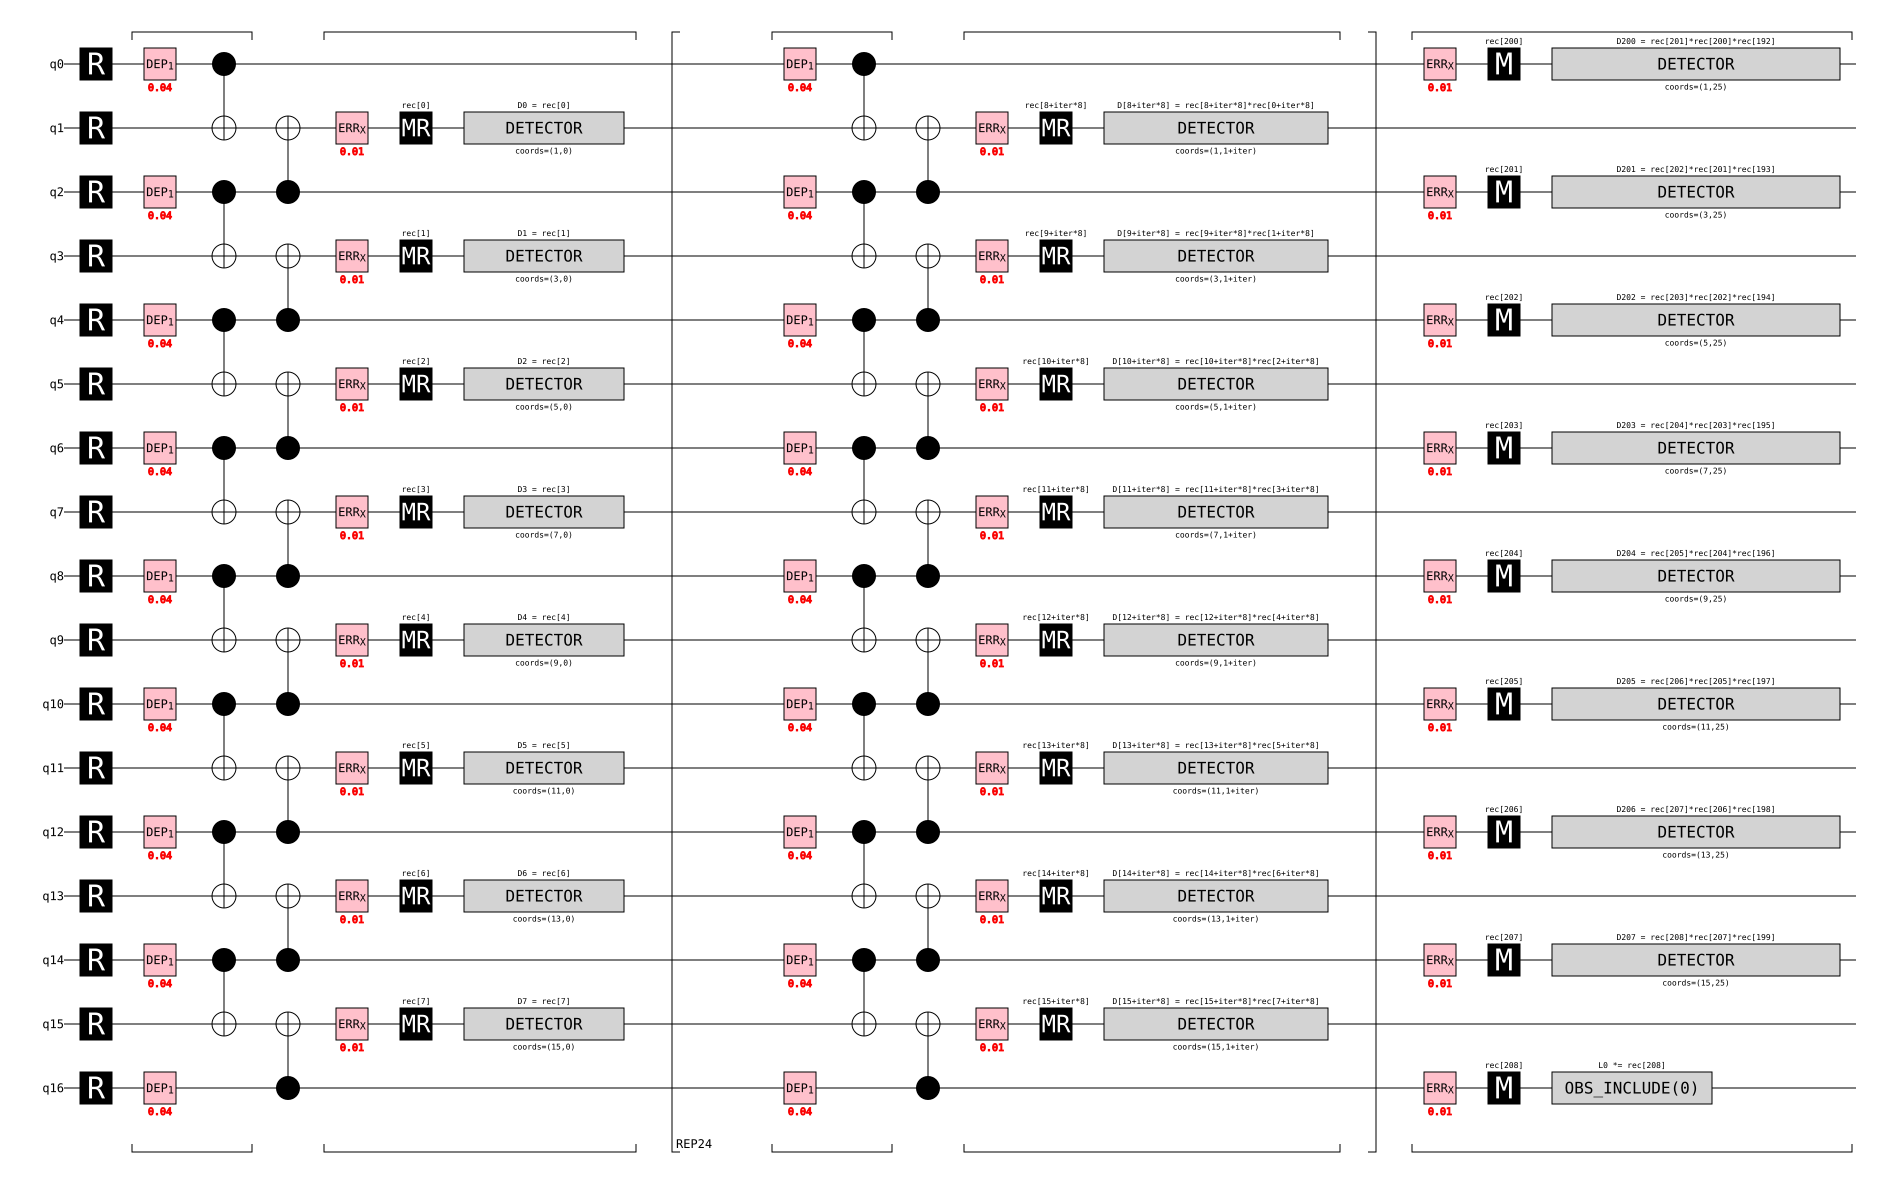

In [ ]:
# Draw a picture of the circuit's timeline as an SVG image. This helps us see how all the operations happen step-by-step.
circuit.diagram('timeline-svg')

## Sampling the Circuit's Measurements
This means I'm repeatedly running my circuit and recording the measurements each time to study its behavior and estimate its error rate. Each run is called a sample. Sampling is done because errors happen randomly, and by running it hundreds or thousands of times, it reveals:
1. How often errors occur.
2. Whether the repetition code detects those errors.
3. How well the repetition code protects the stored quantum information.

In [ ]:
sampler = circuit.compile_sampler()                     # Get the circuit ready to run many times and collect the results of our measurements.
one_sample = sampler.sample(shots=1)[0]                 # Run the circuit just once and get the first set of measurement results.
for k in range(0, len(one_sample), 8):                  # Look at the measurement results in groups of 8. Each group shows the measurements for one full round of error correction.
  timeslice = one_sample[k:k+8]                         # Take a single group of 8 measurement results for a specific round.
  print("".join("1" if e else "_" for e in timeslice))  # Show the results: '1' means an error (a qubit flipped), '_' means no error.

________
________
____11__
____11__
____11__
____11__
____11__
1___11__
1___11__
1___11__
1___11__
1___11__
1___11__
111_11__
111_1111
111_1111
111_1111
_11_11__
111_1111
111_1111
11__1111
111_1111
111_1111
111_1111
111_11__
1_1__1__
_


Here, in the output, we get two things:
1. _ which means no error occurred.
2. 1 which means an error occurred.
When a data qubit gets an error (i.e., flips), it usually remains in the wrong state until the end of the circuit. Because of this, the neighboring stabilizer measurements keep reporting the same error in every round. That is why I get a long streak of 1s in the measurement results.

## Sampling the Circuit's Detectors
 Instead of looking at raw measurements, we can look at the detectors. A detector doesn't report the same error repeatedly. It only reports when something changes (i.e., a detector fires), such as when an error first appears or disappears, making the data much easier to understand.

In [ ]:
detector_sampler = circuit.compile_detector_sampler()      # Get the circuit ready to run and collect 'detector' signals, which are simpler than raw measurements.
one_sample = detector_sampler.sample(shots=1)[0]           # Run the circuit once and get the first set of 'detector' signals.
for k in range(0, len(one_sample), 8):                     # Look at the detector signals in groups of 8, with each group showing results for one error correction round.
  timeslice = one_sample[k:k+8]                            # Take a single group of 8 detector signals for a specific round.
  print("".join("!" if e else "_" for e in timeslice))     # Show the signals: '!' means a detector fired (it saw an error change), '_' means nothing changed.

________
_______!
!_______
________
________
________
________
________
________
________
!_______
________
__!!____
________
________
________
________
________
________
!_______
________
________
________
________
____!!__
________


Now, instead of 1s, the detector detects '!' in pairs. This is because one error affects two nearby stabilizers. These pairs help the decoder to locate the error. At edges, a detector may pair with the boundary instead of another detector. The decoder uses this information to determine whether the logical qubit was flipped. If the logical qubit was flipped an odd number of times, it is corrected. If it is flipped an even number of times, no error correction is needed.

## Using the Detector Error Model and PyMatching
 Stim makes it easier to use a decoder by converting a circuit into a "Detector Error Model (DEM)". A detector error model is a list of all errors in a quantum circuit that indicates how errors appear in measurements.

In [ ]:
dem = circuit.detector_error_model()           # Create a 'Detector Error Model' (DEM) from our circuit. This model shows how different errors in the circuit would make our detectors fire.
                                               # This is important because it helps error-correcting programs (decoders) understand what happened.
# Show a detailed text description of the Detector Error Model.
print(repr(dem))

stim.DetectorErrorModel('''
    error(0.0266667) D0
    error(0.0266667) D0 D1
    error(0.01) D0 D8
    error(0.0266667) D1 D2
    error(0.01) D1 D9
    error(0.0266667) D2 D3
    error(0.01) D2 D10
    error(0.0266667) D3 D4
    error(0.01) D3 D11
    error(0.0266667) D4 D5
    error(0.01) D4 D12
    error(0.0266667) D5 D6
    error(0.01) D5 D13
    error(0.0266667) D6 D7
    error(0.01) D6 D14
    error(0.01) D7 D15
    error(0.0266667) D7 L0
    detector(1, 0) D0
    detector(3, 0) D1
    detector(5, 0) D2
    detector(7, 0) D3
    detector(9, 0) D4
    detector(11, 0) D5
    detector(13, 0) D6
    detector(15, 0) D7
    repeat 23 {
        error(0.0266667) D8
        error(0.0266667) D8 D9
        error(0.01) D8 D16
        error(0.0266667) D9 D10
        error(0.01) D9 D17
        error(0.0266667) D10 D11
        error(0.01) D10 D18
        error(0.0266667) D11 D12
        error(0.01) D11 D19
        error(0.0266667) D12 D13
        error(0.01) D12 D20
        error(0.0266667) D1

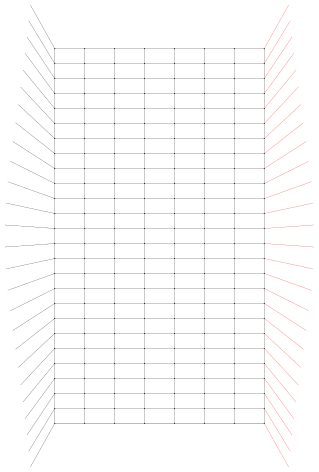

In [ ]:
# Draw the Detector Error Model as a graph. In this graph, circles are detectors, and lines between them show paths where errors can happen, with numbers showing how likely they are.
dem.diagram("matchgraph-svg")

In the detector error model, each node is a detector, and each edge represents a possible error. The decoder matches pairs of detector events to find the most likely errors.

A detector error model (DEM) is easier for a decoder to use than the original quantum circuit because the decoder represents the circuit as a weighted graph, which makes error correction faster and simpler.

#### **Role of PyMatching**
Now I am going to use PyMatching as my decoder. PyMatching is the Minimum-Weight Perfect Matching (MWPM) decoder written by Oscar Higgott. It uses detector events from Stim, builds a weighted graph from the DEM, and uses the MWPM algorithm to find and correct the most likely pattern of errors.

In [ ]:
# Install 'pymatching', a Python tool that helps find and fix errors in quantum circuits.
!pip install pymatching
# Bring in the 'pymatching' library to use its error-fixing tools.
import pymatching
# Bring in the 'numpy', np as alias.
import numpy as np
# Show the version of 'pymatching' we are using.
print(pymatching.__version__)
# Show the version of 'numpy' we are using.
print(np.__version__)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 626.2/626.2 kB 5.4 MB/s eta 0:00:00
2.4.0
2.0.2


In [ ]:
def count_logical_errors(circuit: stim.Circuit, num_shots: int) -> int:
    """Counts the number of logical errors after running a given quantum circuit multiple times.

    Args:
        circuit: The Stim quantum circuit to simulate.
        num_shots: The number of times to run the circuit (samples).

    Returns:
        The total number of logical errors (decoder prediction mismatches with actual logical flips).
    """

    # Get the circuit ready to run many times to produce 'detection events' (error signals).
    sampler = circuit.compile_detector_sampler()
    # Run the circuit 'num_shots' times. We also ask for 'observable_flips' to know if the actual quantum information was truly flipped.
    detection_events, observable_flips = sampler.sample(num_shots, separate_observables=True)

    # Create a 'Detector Error Model' (DEM) from the circuit. We set 'decompose_errors=True' to break down complex errors, making it easier for the error-fixer (decoder) to understand.
    detector_error_model = circuit.detector_error_model(decompose_errors=True)
    # Set up the 'PyMatching' error-fixer (decoder) using the DEM. This decoder will figure out the most likely error pattern.
    matcher = pymatching.Matching.from_detector_error_model(detector_error_model)

    # Use the decoder to guess if the quantum information was flipped, based on the error signals it received.
    predictions = matcher.decode_batch(detection_events)

    num_errors = 0                                                # Start counting logical errors from zero.
    # Go through each run (shot) of the circuit to compare what actually happened with what the decoder guessed.
    for shot in range(num_shots):
       actual_for_shot = observable_flips[shot]                   # See if the actual quantum information was flipped in this run.
       predicted_for_shot = predictions[shot]                     # Get the decoder's guess for this run.
       # If what actually happened doesn't match the decoder's guess, it's a 'logical error'.
       if not np.array_equal(actual_for_shot, predicted_for_shot):
        num_errors +=1                                            # Add one to our count of logical errors if the decoder made a mistake.
    return num_errors                                             # Give back the total number of times the decoder made a wrong guess (logical errors).

Now, I'm running the circuit, which was constructed earlier in this workspace with distance d=9, rounds=25, and a depolarization probability p=0.04 (or 4%). I am executing 100,000 shots, which is done in milliseconds.

In [ ]:
%time
# Decide how many times to run our simulation. 100,000 runs give us good numbers for how often errors happen.
num_shots= 100_000
# Use our function to count how many times the error-fixing program (decoder) made a wrong guess for our circuit.
num_logical_errors = count_logical_errors(circuit, num_shots)
print("There were", num_logical_errors, "wrong predictions(logical errors) out of", num_shots, "shots")

CPU times: user 4 µs, sys: 0 ns, total: 4 µs
Wall time: 7.87 µs
There were 32 wrong predictions(logical errors) out of 100000 shots


As increasing 'physical noise strength' increases the logical error rate, we can verify this by increasing the depolarization probability to 0.13 (or 13%).

In [ ]:
# Make the repetition code circuit again, but this time with a higher chance of errors (depolarization) to see how it affects the logical error rate.
circuit = stim.Circuit.generated(
    "repetition_code:memory",
    distance=9,
    rounds=25,
    before_round_data_depolarization=0.13, # We increased the error chance to 13% (0.13) to see what happens with more noise.
    before_measure_flip_probability=0.01)
# We'll still do 100,000 simulation runs to compare results fairly.
num_shots = 100_000
# Count the logical errors again with the new, higher noise level.
num_logical_errors = count_logical_errors(circuit,num_shots)
print("There were", num_logical_errors, "wrong predictions(logical errors) out of", num_shots, "shots")

There were 3354 wrong predictions(logical errors) out of 100000 shots


Now, I'm calculating the logical error rate. It should be around 1.5e-3.

In [ ]:
# Calculate the 'logical error rate' by dividing the number of mistakes by the total number of runs.
logical_error_rate = num_logical_errors/num_shots
# Show the calculated logical error rate.
logical_error_rate

0.03354

## Estimating the Threshold of a Repetition Code:
* Here I will test an error-correcting repetition code with different physical error rates and different code distances.
* Then I will use **"Monte Carlo Sampling"** to simulate many noisy error runs.
* Monte Carlo Sampling is a computational method that estimates a result by performing many random simulations.
* In this context, it is used to repeat the same experiment many times with randomly generated errors to estimate the probability of failure.
* The logical error rate calculated above is then used to plot **Logical Error Rate vs. Physical Error Rate** for each code distance.
* The point where the curves on the plot intersect is the **threshold of our error-correcting repetition code.**
* **Below the threshold:** Increasing the code distance reduces logical errors.
* **Above the threshold:** Increasing the code distance no longer helps and may even increase logical errors.

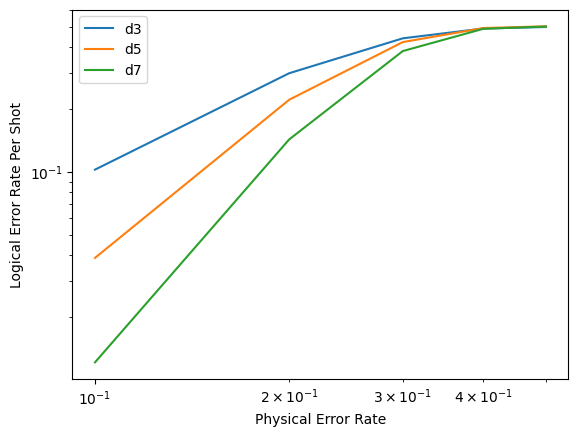

In [ ]:
import matplotlib.pyplot as plt
# We'll run each test 100,000 times to get reliable error rate numbers.
num_shots = 100_000

# We will test different code sizes (d=3, 5, 7) to see how they handle errors.
for d in [3, 5, 7]:
    xs = [] # This list will hold the 'physical' error rates for our graph.
    ys = [] # This list will hold the 'logical' error rates for our graph.
    # For each code size, we'll test various noise levels (physical error rates) to draw a curve.
    for noise in [0.1, 0.2, 0.3, 0.4, 0.5]:
      # Create a new repetition code circuit with the current code size 'd' and noise level 'p'.
      # We set 'rounds = d*3' as a common rule of thumb for how many error correction cycles to run.
      circuit = stim.Circuit.generated(
         "repetition_code:memory",
         distance = d,
         rounds = d*3,
         before_round_data_depolarization = noise)
      # Figure out how many logical errors happen for this specific circuit and number of runs.
      num_error_sampled = count_logical_errors(circuit, num_shots)
      xs.append(noise) # Add the current noise level (physical error rate) to our x-axis data.
      ys.append(num_error_sampled/num_shots) # Add the calculated logical error rate to our y-axis data.
    # Draw a line on the graph showing how logical errors change with physical errors for this specific code size.
    plt.plot(xs, ys, label="d"+str(d))

# Use a special type of graph (log-log scale) for both x and y axes. This is good for showing how error rates change a lot, especially when looking for a 'threshold' point.
plt.loglog()
plt.xlabel("Physical Error Rate") # Label the bottom axis as 'Physical Error Rate'.
plt.ylabel("Logical Error Rate Per Shot") # Label the side axis as 'Logical Error Rate Per Shot'.
plt.legend() # Show a small box explaining which line belongs to which code size (d=3, d=5, d=7).
plt.show()

* The repetition code performs well in these simulations because the results are better than expected, as I used a simple noise model instead of a realistic circuit-level noise model.
* My simulation uses depolarizing errors. Also, the repetition code is not affected by Z errors.
* Since depolarizing errors are both X and Z errors, many **errors don't affect the code** because in a **depolarizing error, 1 out of every 3 errors is a Z error.**

## Using Sinter
 Sinter is a simulation tool that works with Stim to automate large-scale error correction experiments. While Stim only simulates a single quantum circuit, Sinter manages and analyzes many Stim simulations automatically.
##### **Features of Sinter**
* Runs many Stim simulations automatically.
* Tests multiple code distances and physical error rates.
* Collects logical error statistics.
* Supports Monte Carlo Sampling.
* Helps estimate the threshold and generate error-rate plots.

In [ ]:
# Install 'sinter', a tool that helps run many quantum error correction simulations automatically and analyze their results.
!pip install sinter~=1.14
# Bring in the 'sinter' library.
import sinter
# Import 'List' from 'typing'. This helps keep our code neat by telling us what type of information is expected in lists.
from typing import List

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 177.3/177.3 kB 2.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for sinter: filename=sinter-1.16.0-py3-none-any.whl size=197562 sha256=ca47848584404c698ff91198055441058010bd4d1264da677e53ae7d0a12b503
  Stored in directory: /root/.cache/pip/wheels/ac/ad/77/25eadbef8042566ff5bba1963ae8c0239e48e8314bd846c754
Successfully built sinter


In [ ]:
# Set up a list of tasks for our simulations. Each task will test a different circuit setup (different code sizes and noise levels).
tasks = [
    sinter.Task(
        circuit = stim.Circuit.generated(
            "repetition_code:memory",
            distance = d, # Set the size of the error-correcting code ('d').
            rounds = d*3, # Set how many times the error correction process runs. We use 'd*3' as a common practice.
            before_round_data_depolarization=noise, # Add a chance of error ('noise') to the data qubits before each round.
            ),
        json_metadata={'d': d, 'p': noise}, # Save the code size ('d') and noise level ('p') with each task, so we know what we tested.
    )
    for d in [3, 5, 7, 9] # We will test code sizes of 3, 5, 7, and 9.
    for noise in [0.05, 0.08, 0.1, 0.2, 0.3, 0.4, 0.5] # We will test different noise levels, from 5% to 50%.
]

# Run all the simulation tasks and gather the results.
collected_stats: List[sinter.TaskStats]= sinter.collect(
    num_workers = 4, # Use 4 computer cores to run simulations at the same time, making it faster.
    tasks = tasks, # Give 'sinter' the list of tasks we just set up.
    decoders = ['pymatching'], # Tell 'sinter' to use 'pymatching' as the error-fixing program.
    max_shots = 100_000, # Run each task up to 100,000 times to get good, accurate numbers.
    max_errors = 500, # If a task already hits 500 logical errors, stop it early. This saves time if the error rate is very high.
)

I'm now going to make a plot by collecting data from Sinter and creating a professional graph of physical error rate vs. logical error rate per shot. It automatically highlights the region of uncertainty in the estimates.

**Physical Error Rate(p):**
It is the probability that an individual physical qubit or gate operation fails in the circuit.
This is basically the noise we inject in our simulation. It is done in this project using:

                        before_round_data_depolarization
and

                        before_measure_flip_probability

In essence, it is the property of hardware/noise model.


**Logical Error Rate:**
It is basically noise that tells us how often the encoded qubit ends up wrong after QEC code tries to detect and fix errors. It is the noise that actually survives error correction.

It is measured empirically  by running many shots and counting how often the decoder's correction doesn't match the actual error that occurred using:

                          count_logical_error()

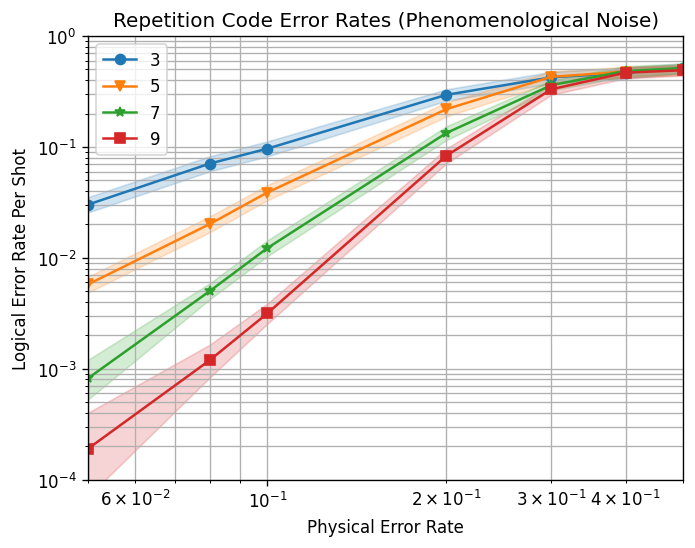

In [ ]:
fig, ax = plt.subplots(1,1)                                # Create an empty space for our plot, with one graph inside.
sinter.plot_error_rate(                                    # Use 'sinter' to draw a special graph showing error rates.
    ax = ax,                                               # Tell 'sinter' to draw on the graph space we just made.
    stats = collected_stats,                               # Give 'sinter' all the results it collected from our simulations.
    x_func = lambda stats: stats.json_metadata['p'],       # Set the bottom (x-axis) of the graph to show the 'physical error rate' (p) from our saved data.
    group_func = lambda stats: stats.json_metadata['d'],   # Group the data by 'code distance' (d), so each code size gets its own line on the graph.
  )
ax.set_ylim(1e-4, 1e-0)                                    # Set the range for the side (y-axis) of the graph from very small (0.0001) to 1. This helps us see tiny error rates better.
ax.set_xlim(5e-2, 5e-1)                                    # Set the range for the bottom (x-axis) of the graph from 0.05 to 0.5.
ax.loglog()                                                # Make both axes use a 'logarithmic scale'. This is helpful for showing when error rates change drastically, like in quantum error correction plots.
ax.set_title("Repetition Code Error Rates (Phenomenological Noise)") # Give our graph a clear title.
ax.set_xlabel("Physical Error Rate")                        # Label the bottom axis 'Physical Error Rate'.
ax.set_ylabel("Logical Error Rate Per Shot")                # Label the side axis 'Logical Error Rate Per Shot'.
ax.grid(which='major')                                     # Add major grid lines to the graph for easier reading.
ax.grid(which='minor')                                     # Add smaller grid lines for more precise reading.
ax.legend()                                                # Show a key on the graph to explain what each colored line represents (each code distance).
fig.set_dpi(120)                                           # Make the image of the graph higher quality by setting its resolution to 120 dots per inch.

### **Results**:
**Below the Threshold:** We see from the graph above that increasing the code distance meaningfully suppresses the logical error rate, e.g., the largest code distance (d = 9) has a much lower logical error rate (larger gap) than the smallest code (d = 3) at a low physical error rate (5 x 10^-2). This is the region where Quantum Error Correction (QEC) pays off and where a quantum computer needs to operate.

*  *Increasing Noise:* We see from the graph that at a higher error rate (e.g., 2 x 10 ^-1) below the threshold, the gap between d = 9 and d = 3 drops drastically. At this point, error correction still works, but its advantages are noise independent.

**Beyond Threshold:** In this region, the physical hardware gets too noisy such that larger codes no longer outperform smaller ones. As a result, it is very hard for the code to keep up because errors are introduced faster than the decoder can correct them.

**At Threshold:** This is the point in the graph where all code distances converge to roughly the same logical error rate. It marks the boundary between the aforementioned regions. At this point, adding more qubits stops being worthwhile and can even backfire slightly.

### **Limitations/Gaps of my Project:**
1. The repetition code only protects against bit-flip (X) errors; it has no mechanism to detect phase-flip (Z) errors (Z-errors also don't have an effect on the repetition code). So, it is not a complete and practical code for real quantum computation, which needs protection against both types of errors.

2. In this project, only simplified phenomenological noise is used rather than correlated, biased noise profiles of real quantum hardware, so it's an "Idealized Noise Model."

3. It is totally a classical simulation and has never been tested or validated against real quantum hardware.

###**Significance of Project:**
Despite its simplicity, this project reproduces the core theoretical behavior that makes quantum error correction the foundation of scalable quantum computing.

By demonstrating and correctly interpreting error correction, even on simplified toy code, shows a working understanding of the central problem of the entire QEC field.

### **Conclusion:**
This project successfully investigates the performance of a quantum error-correcting repetition code under varying noise conditions and code distances. By leveraging the Stim library for circuit simulation and Sinter for automated statistical sweeps up to 100,000 shots per data point, coupled with PyMatching for minimum-weight perfect matching (MWPM) decoding, I have quantitatively demonstrated the fundamental principles of Quantum Error Correction (QEC).